Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline

Load Dataset

In [2]:
parking_data = pd.read_csv('../data/raw/dataset.csv')
print(parking_data.shape)
parking_data.head()

(35717, 4)


,SystemCodeNumber,Capacity,Occupancy,LastUpdated
0,BHMBCCMKT01,577,61,2016-10-04 07:59:42
1,BHMBCCMKT01,577,64,2016-10-04 08:25:42
2,BHMBCCMKT01,577,80,2016-10-04 08:59:42
3,BHMBCCMKT01,577,107,2016-10-04 09:32:46
4,BHMBCCMKT01,577,150,2016-10-04 09:59:48


Clean the Data

In [3]:
print('Before cleaning:', parking_data.shape)

parking_data.dropna(inplace=True)
parking_data.drop_duplicates(keep='first', inplace=True)
parking_data = parking_data[parking_data['Occupancy'] >= 0]
parking_data = parking_data[parking_data['Capacity'] >= 0]

false_data = parking_data[parking_data['Occupancy'] > parking_data['Capacity']]
parking_data = pd.concat([parking_data, false_data]).drop_duplicates(keep=False)

print('After cleaning:', parking_data.shape)
parking_data.describe()

Before cleaning: (35717, 4)
After cleaning: (35116, 4)


,Capacity,Occupancy
count,35116.000000,35116.000000
mean,1407.923966,645.350496
std,1183.011879,660.531340
min,220.000000,0.000000
25%,577.000000,210.000000
50%,863.000000,450.000000
75%,2009.000000,799.000000
max,4675.000000,4327.000000


 Add New Columns

In [4]:
parking_data['OccupancyRate'] = (100.0 * parking_data['Occupancy']) / parking_data['Capacity']

dateTime = parking_data['LastUpdated'].str.split(" ", n=1, expand=True)
parking_data['Date'] = dateTime[0]
parking_data['Time'] = dateTime[1]

day_name = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
parking_data['DayOfWeek'] = pd.to_datetime(parking_data['Date']).dt.dayofweek.apply(lambda x: day_name[x])
parking_data['Hour'] = pd.to_datetime(parking_data['Time']).dt.hour

print(parking_data.info())
parking_data.head()

C:\Users\USER\AppData\Local\Temp\ipykernel_11132\1497674486.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parking_data['Hour'] = pd.to_datetime(parking_data['Time']).dt.hour


<class 'pandas.core.frame.DataFrame'>
Index: 35116 entries, 0 to 35716
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SystemCodeNumber  35116 non-null  object 
 1   Capacity          35116 non-null  int64  
 2   Occupancy         35116 non-null  int64  
 3   LastUpdated       35116 non-null  object 
 4   OccupancyRate     35116 non-null  float64
 5   Date              35116 non-null  object 
 6   Time              35116 non-null  object 
 7   DayOfWeek         35116 non-null  object 
 8   Hour              35116 non-null  int32  
dtypes: float64(1), int32(1), int64(2), object(5)
memory usage: 2.5+ MB
None


,SystemCodeNumber,Capacity,Occupancy,LastUpdated,OccupancyRate,Date,Time,DayOfWeek,Hour
0,BHMBCCMKT01,577,61,2016-10-04 07:59:42,10.571924,2016-10-04,07:59:42,Tue,7
1,BHMBCCMKT01,577,64,2016-10-04 08:25:42,11.091854,2016-10-04,08:25:42,Tue,8
2,BHMBCCMKT01,577,80,2016-10-04 08:59:42,13.864818,2016-10-04,08:59:42,Tue,8
3,BHMBCCMKT01,577,107,2016-10-04 09:32:46,18.544194,2016-10-04,09:32:46,Tue,9
4,BHMBCCMKT01,577,150,2016-10-04 09:59:48,25.996534,2016-10-04,09:59:48,Tue,9


Plot Occupancy Rate Over Time (All Car Parks)

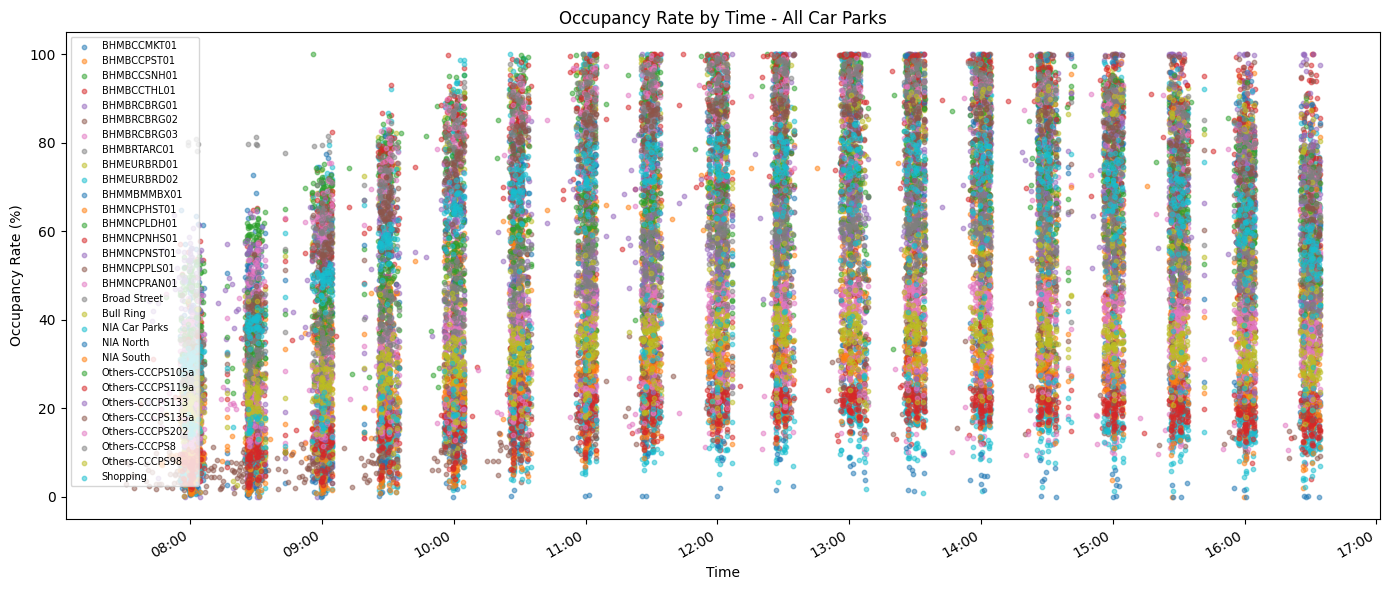

In [5]:
plt.figure(figsize=(14, 6))
park_name = parking_data['SystemCodeNumber'].unique()

for s in park_name:
    rate = parking_data[parking_data['SystemCodeNumber'] == s]['OccupancyRate']
    time = pd.to_datetime(parking_data[parking_data['SystemCodeNumber'] == s]['Time'], format='%H:%M:%S')
    plt.scatter(time, rate, label=s, alpha=0.5, s=10)

plt.gcf().autofmt_xdate()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xlabel('Time')
plt.ylabel('Occupancy Rate (%)')
plt.title('Occupancy Rate by Time - All Car Parks')
plt.legend(fontsize=7, loc='upper left')
plt.tight_layout()
plt.savefig('../data/processed/plot_occupancy_time.png')
plt.show()

Mean Occupancy Rate Per Car Park

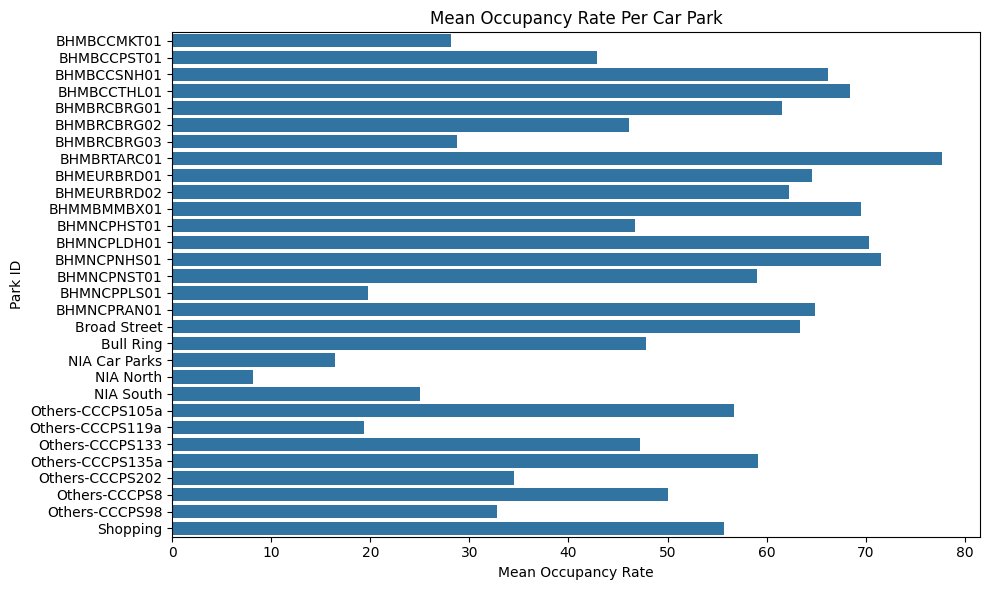

In [6]:
plt.figure(figsize=(10, 6))
mean_occ = parking_data.groupby('SystemCodeNumber')['OccupancyRate'].mean().reset_index()
mean_occ.columns = ['Park ID', 'Mean Occupancy Rate']

sns.barplot(y='Park ID', x='Mean Occupancy Rate', data=mean_occ)
plt.title('Mean Occupancy Rate Per Car Park')
plt.tight_layout()
plt.savefig('../data/processed/plot_mean_occupancy.png')
plt.show()

 Weekday vs Weekend Comparison

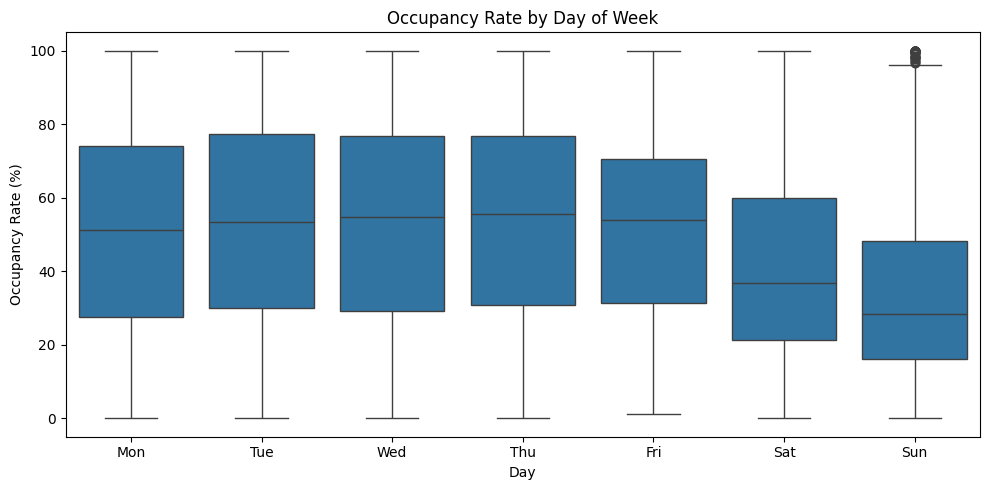

In [7]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='DayOfWeek', y='OccupancyRate', data=parking_data,
            order=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.title('Occupancy Rate by Day of Week')
plt.xlabel('Day')
plt.ylabel('Occupancy Rate (%)')
plt.tight_layout()
plt.savefig('../data/processed/plot_day_occupancy.png')
plt.show()

In [ ]:
Heatmap

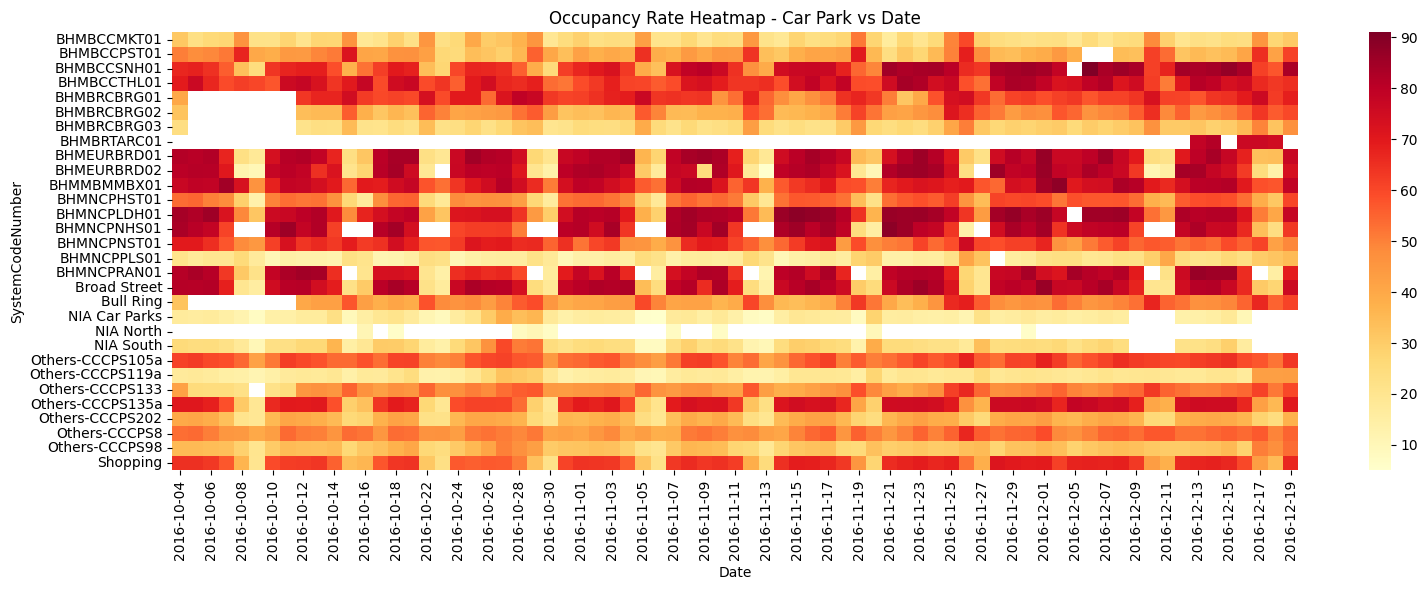

In [8]:
plt.figure(figsize=(16, 6))
heatmap_data = pd.pivot_table(parking_data, values='OccupancyRate',
                               index=['SystemCodeNumber'], columns='Date')
sns.heatmap(heatmap_data, cmap="YlOrRd")
plt.title('Occupancy Rate Heatmap - Car Park vs Date')
plt.tight_layout()
plt.savefig('../data/processed/plot_heatmap.png')
plt.show()

Save Cleaned Data

In [9]:
parking_data.to_csv('../data/processed/cleaned_data.csv', index=False)
print("Cleaned data saved to data/processed/cleaned_data.csv")
print("Shape:", parking_data.shape)

Cleaned data saved to data/processed/cleaned_data.csv
Shape: (35116, 9)
